In [1]:
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

train_data = datasets.FashionMNIST(root="data", train=True,  download=True, transform=ToTensor())
test_data  = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor())

def loader(data, batchsize: int = 1):
    # FashionMNIST z torchvision zwraca obrazy 1×28×28 w zakresie [0, 1];
    # DataLoader sam składa batch o wymiarze (N, 1, 28, 28) i koduje etykiety jako liczby 0..9
    return DataLoader(data, batch_size=batchsize, shuffle=True)

net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=3, padding=1, bias=False),    # 54 parametry
    nn.MaxPool2d(2),
    nn.Conv2d(6, 16, kernel_size=3, padding=1, bias=False),   # 864 parametry
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(784, 84), nn.ReLU(),                           # 65_940 parametrów
    nn.Dropout(0.4),
    nn.Linear(84, 10),                                       # 850 parametrów
)
net   # łącznie 67_708 parametrów

Sequential(
  (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=784, out_features=84, bias=True)
  (6): ReLU()
  (7): Dropout(p=0.4, inplace=False)
  (8): Linear(in_features=84, out_features=10, bias=True)
)

In [2]:
from collections import namedtuple

def onecold(y):
    # odpowiednik Flux.onecold – zwraca indeks (etykietę) największej wartości
    return y.argmax(dim=1)

x1, y1 = next(iter(loader(train_data)))
y1hat = net(x1)
print("hcat(onecold(y1hat), onecold(y1)) =", torch.stack([onecold(y1hat), y1]).T.tolist())

Metrics = namedtuple("Metrics", ["loss", "acc", "split"])

def loss_and_accuracy(model, data, split):
    # przepuszczamy cały zbiór przez sieć (w porcjach, aby oszczędzić pamięć) i liczymy stratę oraz trafność
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for x, y in DataLoader(data, batch_size=1000):
            yhat = model(x)
            total_loss += nn.functional.cross_entropy(yhat, y, reduction="sum").item()
            correct += (onecold(yhat) == y).sum().item()
            n += len(y)
    loss = total_loss / n
    acc = round(100 * correct / n, 2)
    return Metrics(loss=loss, acc=acc, split=split)

print("loss_and_accuracy(net, test_data) =", loss_and_accuracy(net, test_data, "test"))  # ok. 10% przed treningiem

train_log = []
settings = dict(
    eta=1e-2,
    epochs=3,
    batchsize=10,
)
opt_state = torch.optim.SGD(net.parameters(), lr=settings["eta"])

hcat(onecold(y1hat), onecold(y1)) = [[9, 9]]


loss_and_accuracy(net, test_data) = Metrics(loss=2.304966943359375, acc=8.97, split='test')


In [3]:
import time
import numpy as np

accuracy = np.zeros((settings["epochs"], 2))
for epoch in range(1, settings["epochs"] + 1):
    net.train()
    t0 = time.perf_counter()
    for x, y in loader(train_data, batchsize=settings["batchsize"]):
        opt_state.zero_grad()
        loss = nn.functional.cross_entropy(net(x), y)
        loss.backward()
        opt_state.step()
    print(f"{time.perf_counter() - t0:10.6f} seconds")

    loss, acc, _ = loss_and_accuracy(net, train_data, "train")
    test_loss, test_acc, _ = loss_and_accuracy(net, test_data, "test")
    print(f"┌ Info: {epoch}\n│   acc = {acc}\n│   test_acc = {test_acc}\n└")
    train_log.append(dict(epoch=epoch, loss=loss, acc=acc, test_loss=test_loss, test_acc=test_acc))
    accuracy[epoch - 1, 0] = acc
    accuracy[epoch - 1, 1] = test_acc

 23.315434 seconds


┌ Info: 1
│   acc = 81.62
│   test_acc = 80.76
└


 20.497249 seconds


┌ Info: 2
│   acc = 84.15
│   test_acc = 82.64
└


 20.054568 seconds


┌ Info: 3
│   acc = 87.29
│   test_acc = 86.21
└


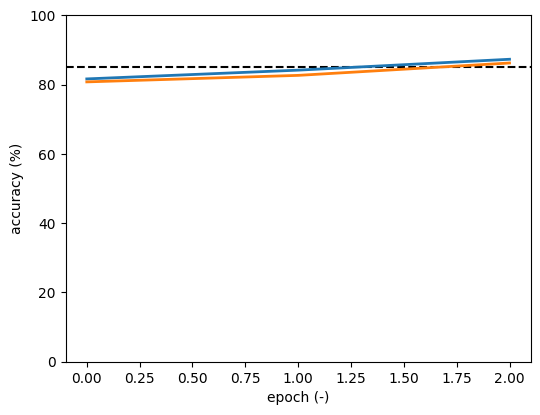

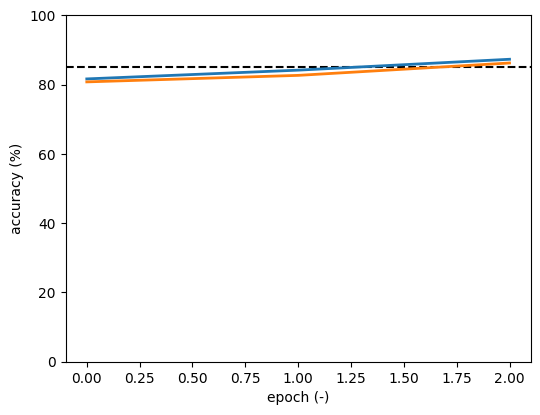

In [4]:
import matplotlib.pyplot as plt

fig, gca = plt.subplots(figsize=(6, 4.5))
gca.set_xlabel("epoch (-)")
gca.set_ylabel("accuracy (%)")
gca.axhline(85, linestyle="--", color="black")
gca.plot(accuracy[:, 0], linewidth=2)
gca.plot(accuracy[:, 1], linewidth=2)
gca.set_ylim(0, 100)
fig

In [5]:
x1, y1 = next(iter(loader(test_data)))
y1hat = net(x1)
print("hcat(onecold(y1hat), onecold(y1)) =", torch.stack([onecold(y1hat), y1]).T.tolist())
print("loss_and_accuracy(net, test_data) =", loss_and_accuracy(net, test_data, "test"))

hcat(onecold(y1hat), onecold(y1)) = [[8, 8]]


loss_and_accuracy(net, test_data) = Metrics(loss=0.37541219787597657, acc=86.21, split='test')


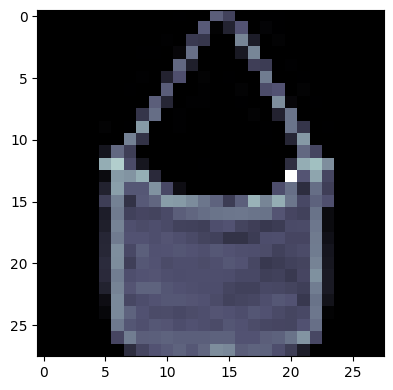

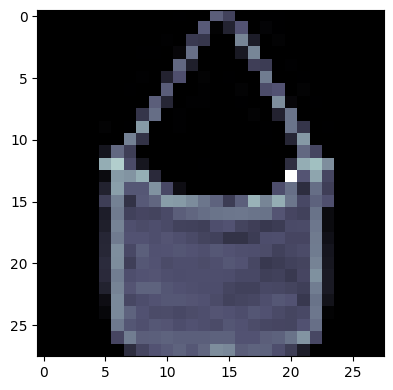

In [6]:
# pojedynczy obraz z batcha (kanał 0) wyświetlony jako mapa cieplna w odcieniach szarości
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.imshow(x1[0, 0].numpy(), cmap="bone")
ax.set_aspect("equal")
fig